In [78]:
# ============================================================
# Cell 1: Install Required Libraries
# Project : MLCAFormer-Lite for Traffic Flow Forecasting
# Dataset : PEMSD4
# ============================================================

!pip -q install torchinfo
!pip -q install networkx
!pip -q install tqdm
!pip -q install scikit-learn

In [79]:
# ============================================================
# Cell 2: Import Libraries
# ============================================================

import os
import gc
import math
import time
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchinfo import summary
from tqdm.auto import tqdm

print("="*60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Running Device  :", DEVICE)
print("="*60)

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
Running Device  : cuda


In [80]:
# ============================================================
# Cell 3: Global Configuration
# ============================================================

class CFG:

    RANDOM_SEED = 42

    ############################
    # Data
    ############################

    INPUT_LENGTH = 12
    PRED_LENGTH = 12

    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.10
    TEST_RATIO = 0.20

    ############################
    # Training
    ############################

    BATCH_SIZE = 16

    EPOCHS = 20

    LEARNING_RATE = 1e-3

    WEIGHT_DECAY = 1e-5

    ############################
    # MLCAFormer
    ############################

    D_MODEL = 64

    NUM_HEADS = 4

    NUM_LAYERS = 2

    DROPOUT = 0.1

cfg = CFG()

In [81]:
# ============================================================
# Cell 4: Reproducibility
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.RANDOM_SEED)

print("Random Seed =", cfg.RANDOM_SEED)

Random Seed = 42


In [82]:
# ============================================================
# Cell 5: GPU Information
# ============================================================

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    total = torch.cuda.get_device_properties(0).total_memory

    print("GPU Memory :", total/1024**3,"GB")

else:

    print("Running on CPU")

GPU : Tesla T4
GPU Memory : 14.56317138671875 GB


In [83]:
# ============================================================
# Cell 6: Load PEMSD4 Dataset
# ============================================================

DYNA_FILE = "PEMSD4.dyna"
GEO_FILE  = "PEMSD4.geo"
REL_FILE  = "PEMSD4.rel"

traffic_df = pd.read_csv('/content/PEMSD4.dyna')

geo_df = pd.read_csv('/content/PEMSD4.geo')

rel_df = pd.read_csv('/content/PEMSD4.rel')

print("="*60)

print("Traffic :", traffic_df.shape)

print("Geo     :", geo_df.shape)

print("Relation:", rel_df.shape)

print("="*60)


Traffic : (5216544, 7)
Geo     : (307, 3)
Relation: (340, 5)


In [84]:
# ============================================================
# Cell 7: Preview Dataset
# ============================================================

display(traffic_df.head())

display(geo_df.head())

display(rel_df.head())

,dyna_id,type,time,entity_id,traffic_flow,traffic_occupancy,traffic_speed
0,0,state,2018-01-01T00:00:00Z,0,62.0,0.0077,67.9
1,1,state,2018-01-01T00:05:00Z,0,61.0,0.0074,67.3
2,2,state,2018-01-01T00:10:00Z,0,71.0,0.0093,68.4
3,3,state,2018-01-01T00:15:00Z,0,86.0,0.0112,67.8
4,4,state,2018-01-01T00:20:00Z,0,103.0,0.0144,67.4


,geo_id,type,coordinates
0,0,Point,[]
1,1,Point,[]
2,2,Point,[]
3,3,Point,[]
4,4,Point,[]


,rel_id,type,origin_id,destination_id,cost
0,0,geo,73,5,352.6
1,1,geo,5,154,347.2
2,2,geo,154,263,392.9
3,3,geo,263,56,440.8
4,4,geo,56,96,374.6


In [85]:
# ============================================================
# Cell 8: Dataset Information
# ============================================================

print("="*60)
print("Traffic Dataset")
print("="*60)

traffic_df.info()

print()

print("="*60)
print("Geo Dataset")
print("="*60)

geo_df.info()

print()

print("="*60)
print("Relation Dataset")
print("="*60)

rel_df.info()

Traffic Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5216544 entries, 0 to 5216543
Data columns (total 7 columns):
 #   Column             Dtype  
---  ------             -----  
 0   dyna_id            int64  
 1   type               object 
 2   time               object 
 3   entity_id          int64  
 4   traffic_flow       float64
 5   traffic_occupancy  float64
 6   traffic_speed      float64
dtypes: float64(3), int64(2), object(2)
memory usage: 278.6+ MB

Geo Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   geo_id       307 non-null    int64 
 1   type         307 non-null    object
 2   coordinates  307 non-null    object
dtypes: int64(1), object(2)
memory usage: 7.3+ KB

Relation Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 5 columns):
 #   Column          Non-N

In [86]:
# ============================================================
# Cell 9: Check Missing Values
# ============================================================

print("="*60)

print("Traffic")

print(traffic_df.isnull().sum())

print("="*60)

print("Geo")

print(geo_df.isnull().sum())

print("="*60)

print("Relation")

print(rel_df.isnull().sum())

Traffic
dyna_id              0
type                 0
time                 0
entity_id            0
traffic_flow         0
traffic_occupancy    0
traffic_speed        0
dtype: int64
Geo
geo_id         0
type           0
coordinates    0
dtype: int64
Relation
rel_id            0
type              0
origin_id         0
destination_id    0
cost              0
dtype: int64


In [87]:
# ============================================================
# Cell 10: Basic Statistics
# ============================================================

display(

traffic_df[

["traffic_flow",

"traffic_speed",

"traffic_occupancy"]

].describe()

)

,traffic_flow,traffic_speed,traffic_occupancy
count,5.216544e+06,5.216544e+06,5.216544e+06
mean,2.117008e+02,6.347061e+01,5.283677e-02
std,1.580684e+02,8.355702e+00,4.947012e-02
min,0.000000e+00,3.000000e+00,0.000000e+00
25%,8.100000e+01,6.250000e+01,2.130000e-02
50%,1.800000e+02,6.560000e+01,4.430000e-02
75%,3.190000e+02,6.780000e+01,6.910000e-02
max,9.190000e+02,8.520000e+01,7.716000e-01


In [88]:
# ============================================================
# Cell 11: Select Multi-Feature Columns
# ============================================================

# Keep only the columns required for multivariate forecasting
traffic_df = traffic_df[
    [
        "time",
        "entity_id",
        "traffic_flow",
        "traffic_occupancy",
        "traffic_speed"
    ]
]

traffic_df.head()

,time,entity_id,traffic_flow,traffic_occupancy,traffic_speed
0,2018-01-01T00:00:00Z,0,62.0,0.0077,67.9
1,2018-01-01T00:05:00Z,0,61.0,0.0074,67.3
2,2018-01-01T00:10:00Z,0,71.0,0.0093,68.4
3,2018-01-01T00:15:00Z,0,86.0,0.0112,67.8
4,2018-01-01T00:20:00Z,0,103.0,0.0144,67.4


In [89]:
# ============================================================
# Cell 12: Convert Time Format
# ============================================================

traffic_df["time"] = pd.to_datetime(traffic_df["time"])

traffic_df = traffic_df.sort_values(
    by=["time", "entity_id"]
).reset_index(drop=True)

print("Traffic Shape :", traffic_df.shape)

traffic_df.head()

Traffic Shape : (5216544, 5)


,time,entity_id,traffic_flow,traffic_occupancy,traffic_speed
0,2018-01-01 00:00:00+00:00,0,62.0,0.0077,67.9
1,2018-01-01 00:00:00+00:00,1,56.0,0.0112,68.4
2,2018-01-01 00:00:00+00:00,2,90.0,0.0143,68.2
3,2018-01-01 00:00:00+00:00,3,32.0,0.0074,66.3
4,2018-01-01 00:00:00+00:00,4,19.0,0.0073,65.4


In [90]:
# ============================================================
# Cell 13: Create Feature Matrices
# ============================================================

flow_matrix = traffic_df.pivot(
    index="time",
    columns="entity_id",
    values="traffic_flow"
)

speed_matrix = traffic_df.pivot(
    index="time",
    columns="entity_id",
    values="traffic_speed"
)

occupancy_matrix = traffic_df.pivot(
    index="time",
    columns="entity_id",
    values="traffic_occupancy"
)

print("Flow Matrix      :", flow_matrix.shape)
print("Speed Matrix     :", speed_matrix.shape)
print("Occupancy Matrix :", occupancy_matrix.shape)

Flow Matrix      : (16992, 307)
Speed Matrix     : (16992, 307)
Occupancy Matrix : (16992, 307)


In [91]:
# ============================================================
# Cell 14: Fill Missing Values
# ============================================================

flow_matrix = flow_matrix.ffill().bfill()

speed_matrix = speed_matrix.ffill().bfill()

occupancy_matrix = occupancy_matrix.ffill().bfill()

print("Missing Flow :", flow_matrix.isna().sum().sum())
print("Missing Speed :", speed_matrix.isna().sum().sum())
print("Missing Occupancy :", occupancy_matrix.isna().sum().sum())

Missing Flow : 0
Missing Speed : 0
Missing Occupancy : 0


In [92]:
# ============================================================
# Cell 15: Convert to NumPy
# ============================================================

flow = flow_matrix.values.astype(np.float32)

speed = speed_matrix.values.astype(np.float32)

occupancy = occupancy_matrix.values.astype(np.float32)

print(flow.shape)
print(speed.shape)
print(occupancy.shape)

(16992, 307)
(16992, 307)
(16992, 307)


In [93]:
# ============================================================
# Cell 16: Build Multi-Feature Tensor
# Shape: (Time, Nodes, Features)
# ============================================================

traffic_data = np.stack(

    [
        flow,
        speed,
        occupancy
    ],

    axis=-1

)

print("="*60)
print("Traffic Tensor Shape")
print(traffic_data.shape)
print("="*60)

Traffic Tensor Shape
(16992, 307, 3)


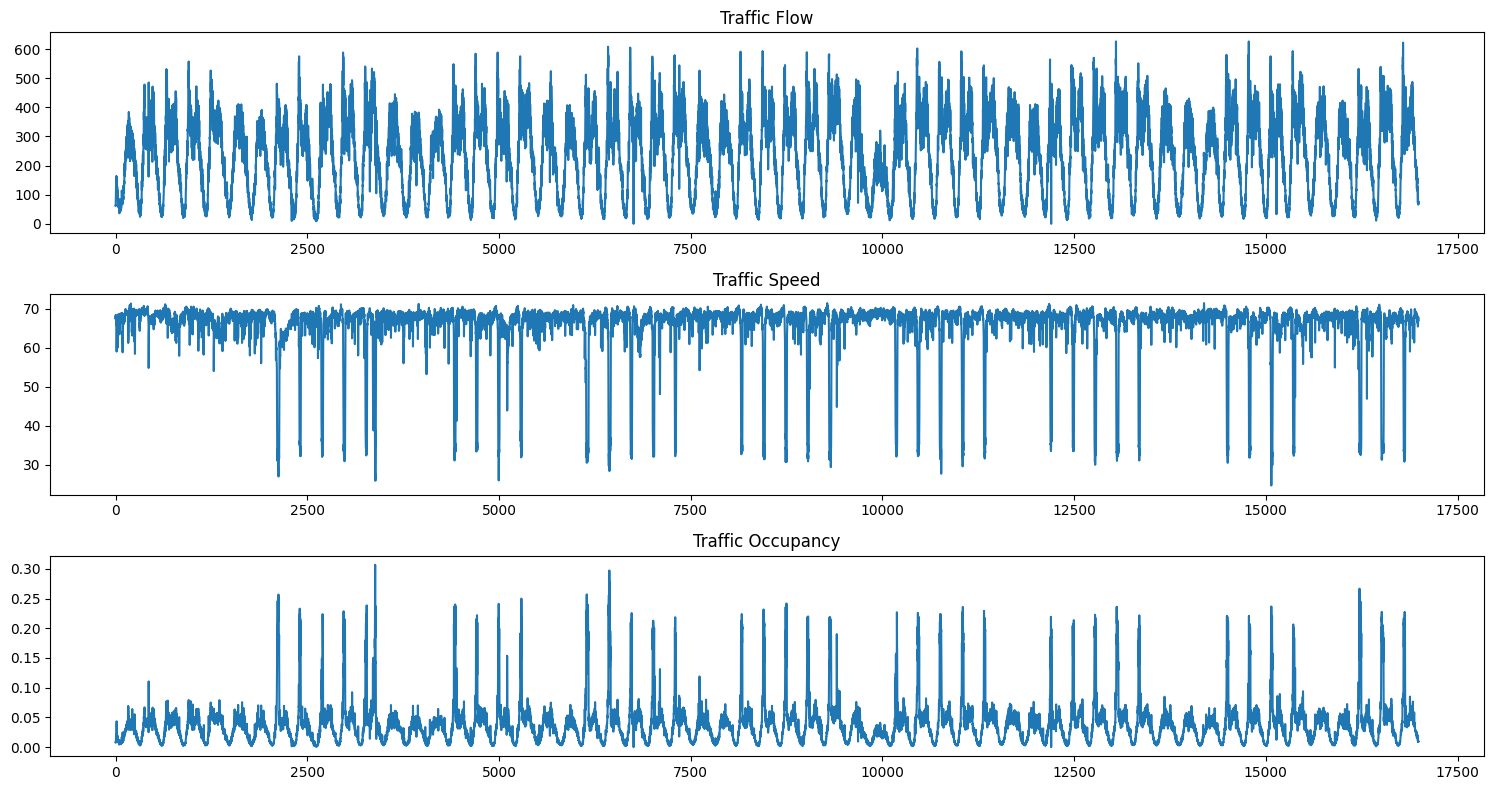

In [154]:
# ============================================================
# Cell 17: Visualize Features
# ============================================================

os.makedirs("results", exist_ok=True)

fig, ax = plt.subplots(
    3,
    1,
    figsize=(15,8)
)

ax[0].plot(
    traffic_data[:,0,0]
)

ax[0].set_title("Traffic Flow")

ax[1].plot(
    traffic_data[:,0,1]
)

ax[1].set_title("Traffic Speed")

ax[2].plot(
    traffic_data[:,0,2]
)

ax[2].set_title("Traffic Occupancy")

plt.tight_layout()
plt.savefig(
    "results/traffic_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [95]:
# ============================================================
# Cell 19: Check Tensor Information
# ============================================================

print("="*60)

print("Tensor Shape :", traffic_data.shape)

print("Tensor Type :", traffic_data.dtype)

print("Memory : %.2f MB"%(
traffic_data.nbytes/1024/1024
))

print("="*60)

Tensor Shape : (16992, 307, 3)
Tensor Type : float32
Memory : 59.70 MB


In [96]:
# ============================================================
# Cell 20: Preview One Time Step
# ============================================================

traffic_data[0]

array([[6.200e+01, 6.790e+01, 7.700e-03],
       [5.600e+01, 6.840e+01, 1.120e-02],
       [9.000e+01, 6.820e+01, 1.430e-02],
       [3.200e+01, 6.630e+01, 7.400e-03],
       [1.900e+01, 6.540e+01, 7.300e-03],
       [6.800e+01, 6.870e+01, 1.130e-02],
       [2.400e+01, 6.610e+01, 7.800e-03],
       [2.400e+01, 6.910e+01, 5.400e-03],
       [3.100e+01, 6.800e+01, 5.900e-03],
       [3.100e+01, 6.610e+01, 3.700e-03],
       [9.000e+01, 7.000e+01, 1.300e-02],
       [3.500e+01, 6.790e+01, 8.100e-03],
       [1.240e+02, 6.970e+01, 1.400e-02],
       [3.600e+01, 6.590e+01, 9.500e-03],
       [2.700e+01, 6.690e+01, 6.400e-03],
       [3.700e+01, 6.750e+01, 7.300e-03],
       [6.800e+01, 6.660e+01, 1.090e-02],
       [9.100e+01, 6.800e+01, 1.510e-02],
       [7.500e+01, 6.870e+01, 8.400e-03],
       [7.100e+01, 6.680e+01, 1.230e-02],
       [3.000e+01, 6.920e+01, 7.200e-03],
       [2.100e+01, 6.600e+01, 9.400e-03],
       [1.600e+01, 6.700e+01, 5.800e-03],
       [3.000e+01, 6.770e+01, 8.40

In [97]:
# ============================================================
# Cell 21: Min-Max Normalizer
# ============================================================

class MinMaxNormalizer:
    """
    Min-Max Normalization for Traffic Data
    Shape:
        (Time, Nodes, Features)
    """

    def __init__(self):

        self.data_min = None
        self.data_max = None

    def fit(self, data):

        self.data_min = data.min(axis=0, keepdims=True)

        self.data_max = data.max(axis=0, keepdims=True)

    def transform(self, data):

        return (
            data - self.data_min
        ) / (
            self.data_max - self.data_min + 1e-8
        )

    def inverse_transform(self, data):

        return (
            data * (self.data_max - self.data_min + 1e-8)
        ) + self.data_min

In [98]:
# ============================================================
# Cell 22: Normalize Dataset
# ============================================================

# normalizer = MinMaxNormalizer()

# normalizer.fit(traffic_data)

# traffic_data = normalizer.transform(traffic_data)

# print("="*60)

# print("Data Range")

# print("Min :", traffic_data.min())

# print("Max :", traffic_data.max())

# print("="*60)

In [99]:
# ============================================================
# Cell 23: Sliding Window
# ============================================================

INPUT_LENGTH = cfg.INPUT_LENGTH
PRED_LENGTH = cfg.PRED_LENGTH


def create_sliding_window(data, input_len, pred_len):

    X = []

    Y = []

    total_length = len(data)

    for i in range(total_length - input_len - pred_len + 1):

        X.append(
            data[
                i:i + input_len
            ]
        )

        # chỉ dự báo traffic_flow
        Y.append(
            data[
                i + input_len:
                i + input_len + pred_len,
                :,
                0
            ]
        )

    return np.array(X), np.array(Y)

In [100]:
# ============================================================
# Cell 24: Create Samples
# ============================================================

X, Y = create_sliding_window(

    traffic_data,

    INPUT_LENGTH,

    PRED_LENGTH

)

print("=" * 60)

print("Input Shape :", X.shape)

print("Target Shape:", Y.shape)

print("=" * 60)

Input Shape : (16969, 12, 307, 3)
Target Shape: (16969, 12, 307)


In [101]:
# ============================================================
# Cell 25: Train / Validation / Test Split
# ============================================================

num_samples = len(X)

train_end = int(num_samples * cfg.TRAIN_RATIO)

val_end = int(
    num_samples *
    (cfg.TRAIN_RATIO + cfg.VAL_RATIO)
)

X_train = X[:train_end]

Y_train = Y[:train_end]

X_val = X[train_end:val_end]

Y_val = Y[train_end:val_end]

X_test = X[val_end:]

Y_test = Y[val_end:]

print("=" * 60)

print("Train :", X_train.shape)

print("Valid :", X_val.shape)

print("Test  :", X_test.shape)

print("=" * 60)

Train : (11878, 12, 307, 3)
Valid : (1697, 12, 307, 3)
Test  : (3394, 12, 307, 3)


In [102]:
# ============================================================
# Cell 30: Number of Nodes
# ============================================================

NUM_NODES = len(geo_df)

print("=" * 60)

print("Number of Sensors :", NUM_NODES)

print("=" * 60)

Number of Sensors : 307


In [103]:
# ============================================================
# Cell 25.5: Normalize Data After Split
# ============================================================


normalizer = MinMaxNormalizer()


# lấy dữ liệu TRAIN để fit scaler
train_for_scaler = X_train.reshape(
    -1,
    NUM_NODES,
    3
)


normalizer.fit(
    train_for_scaler
)



def normalize_X(X):

    original_shape = X.shape

    X = X.reshape(
        -1,
        NUM_NODES,
        3
    )

    X = normalizer.transform(X)

    return X.reshape(original_shape)



def normalize_Y(Y):

    flow_min = normalizer.data_min[:,:,0]

    flow_max = normalizer.data_max[:,:,0]


    Y = (
        Y - flow_min
    ) / (
        flow_max - flow_min + 1e-8
    )

    return Y



X_train = normalize_X(X_train)

X_val = normalize_X(X_val)

X_test = normalize_X(X_test)



Y_train = normalize_Y(Y_train)

Y_val = normalize_Y(Y_val)

Y_test = normalize_Y(Y_test)



print("="*60)

print("After Normalization")

print("X_train :", X_train.shape)

print("Y_train :", Y_train.shape)

print("Min :", X_train.min())

print("Max :", X_train.max())

print("="*60)

After Normalization
X_train : (11878, 12, 307, 3)
Y_train : (11878, 12, 307)
Min : 0.0
Max : 1.0


In [104]:
# ============================================================
# Cell 26: PyTorch Dataset
# ============================================================

class TrafficDataset(Dataset):

    def __init__(self, X, Y):

        self.X = torch.FloatTensor(X)

        self.Y = torch.FloatTensor(Y)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.Y[idx]

In [105]:
# ============================================================
# Cell 27: Build Dataset
# ============================================================

train_dataset = TrafficDataset(

    X_train,

    Y_train

)

val_dataset = TrafficDataset(

    X_val,

    Y_val

)

test_dataset = TrafficDataset(

    X_test,

    Y_test
)

print(len(train_dataset))

print(len(val_dataset))

print(len(test_dataset))

11878
1697
3394


In [106]:
# ============================================================
# Cell 28: DataLoader
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=cfg.BATCH_SIZE,

    shuffle=True,

    drop_last=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=cfg.BATCH_SIZE,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=cfg.BATCH_SIZE,

    shuffle=False

)

print("DataLoader Ready!")

DataLoader Ready!


In [107]:
# ============================================================
# Cell 29: Verify DataLoader
# ============================================================

sample_x, sample_y = next(iter(train_loader))

print("=" * 60)

print("Input Tensor :", sample_x.shape)

print("Target Tensor:", sample_y.shape)

print("=" * 60)

Input Tensor : torch.Size([16, 12, 307, 3])
Target Tensor: torch.Size([16, 12, 307])


In [108]:
# ============================================================
# Cell 31: Build Adjacency Matrix
# ============================================================

adj_matrix = np.zeros(
    (NUM_NODES, NUM_NODES),
    dtype=np.float32
)

for _, row in rel_df.iterrows():

    src = int(row["origin_id"])

    dst = int(row["destination_id"])

    adj_matrix[src, dst] = 1.0
    adj_matrix[dst, src] = 1.0

print("="*60)
print("Adjacency Shape :", adj_matrix.shape)
print("Number of Edges :", int(adj_matrix.sum()/2))
print("="*60)

Adjacency Shape : (307, 307)
Number of Edges : 340


In [109]:
# ============================================================
# Cell 32: Add Self Loop
# ============================================================

adj_matrix = adj_matrix + np.eye(NUM_NODES)

print("Diagonal Sum :", np.trace(adj_matrix))

Diagonal Sum : 307.0


In [110]:
# ============================================================
# Cell 33: Normalize Adjacency Matrix
# ============================================================

degree = np.sum(adj_matrix, axis=1)

degree_inv = np.power(degree, -0.5)

degree_inv[np.isinf(degree_inv)] = 0

D = np.diag(degree_inv)

adj_matrix = D @ adj_matrix @ D

print(adj_matrix.shape)

(307, 307)


In [111]:
# ============================================================
# Cell 34: Convert Graph to Tensor
# ============================================================

adj_matrix = torch.FloatTensor(
    adj_matrix
).to(DEVICE)

print(adj_matrix.shape)

torch.Size([307, 307])


In [149]:
import os
os.makedirs("results", exist_ok=True)

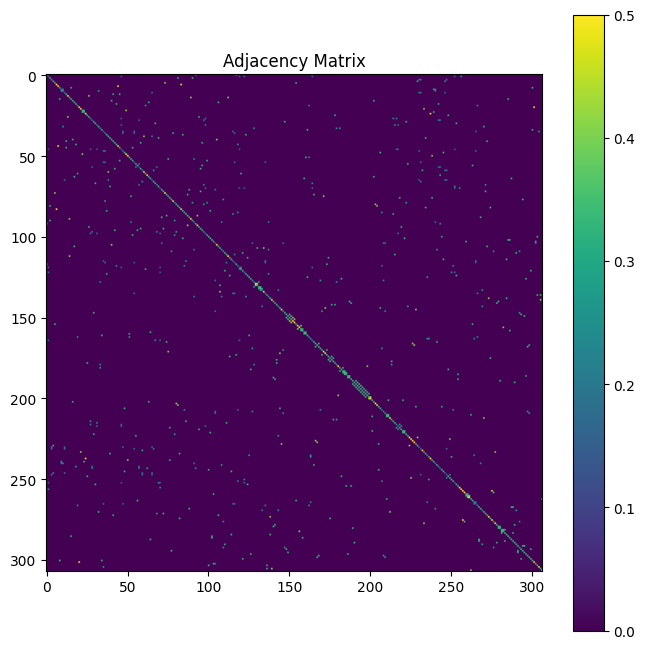

In [150]:
# ============================================================
# Cell 35: Visualize Adjacency Matrix
# ============================================================

plt.figure(figsize=(8,8))

plt.imshow(adj_matrix.cpu())

plt.title("Adjacency Matrix")

plt.colorbar()
plt.savefig(
    "results/adjacency_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
# ============================================================
# Cell 36: Input Projection
# ============================================================

class InputProjection(nn.Module):
    """
    Project input features into latent embedding space.

    Input:
        (B, T, N, F)

    Output:
        (B, T, N, D)
    """

    def __init__(self,
                 input_dim=3,
                 d_model=cfg.D_MODEL):

        super().__init__()

        self.projection = nn.Sequential(

            nn.Linear(input_dim, d_model),

            nn.ReLU(),

            nn.Dropout(cfg.DROPOUT)

        )

    def forward(self, x):

        return self.projection(x)

In [114]:
# ============================================================
# Cell 37: Positional Encoding
# ============================================================

class PositionalEncoding(nn.Module):

    def __init__(self,
                 d_model,
                 max_len=500):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(

            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            )

            *

            (-math.log(10000.0) / d_model)

        )

        pe[:, 0::2] = torch.sin(position * div_term)

        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0).unsqueeze(2)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

In [115]:
# ============================================================
# Cell 38: Spatial Embedding
# ============================================================

class SpatialEmbedding(nn.Module):

    def __init__(self,
                 num_nodes,
                 d_model):

        super().__init__()

        self.embedding = nn.Parameter(

            torch.randn(

                1,
                1,
                num_nodes,
                d_model

            )

        )

    def forward(self, x):

        return x + self.embedding

In [116]:
# ============================================================
# Cell 39: Temporal Embedding
# ============================================================

class TemporalEmbedding(nn.Module):

    def __init__(self,
                 seq_len,
                 d_model):

        super().__init__()

        self.embedding = nn.Parameter(

            torch.randn(

                1,
                seq_len,
                1,
                d_model

            )

        )

    def forward(self, x):

        return x + self.embedding

In [117]:
# ============================================================
# Cell 40: Embedding Layer
# ============================================================

class EmbeddingLayer(nn.Module):

    def __init__(self):

        super().__init__()

        self.input_projection = InputProjection(

            input_dim=3,

            d_model=cfg.D_MODEL

        )

        self.position = PositionalEncoding(

            cfg.D_MODEL,

            cfg.INPUT_LENGTH

        )

        self.spatial = SpatialEmbedding(

            NUM_NODES,

            cfg.D_MODEL

        )

        self.temporal = TemporalEmbedding(

            cfg.INPUT_LENGTH,

            cfg.D_MODEL

        )

    def forward(self, x):

        x = self.input_projection(x)

        x = self.position(x)

        x = self.spatial(x)

        x = self.temporal(x)

        return x

In [118]:
# ============================================================
# Cell 41: Test Embedding
# ============================================================

embedding = EmbeddingLayer().to(DEVICE)

sample_x = sample_x.to(DEVICE)

out = embedding(sample_x)

print("="*60)

print("Input :", sample_x.shape)

print("Output:", out.shape)

print("="*60)

Input : torch.Size([16, 12, 307, 3])
Output: torch.Size([16, 12, 307, 64])


In [119]:
# ============================================================
# Cell 42: Temporal Causal Attention
# ============================================================

class TemporalCausalAttention(nn.Module):
    """
    Temporal Self-Attention with causal masking.
    Input : (B, T, N, D)
    Output: (B, T, N, D)
    """

    def __init__(self, d_model, num_heads):

        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=cfg.DROPOUT,
            batch_first=True
        )

    def forward(self, x):

        B, T, N, D = x.shape

        # (B*N,T,D)
        x = x.permute(0,2,1,3).reshape(B*N,T,D)

        # causal mask
        mask = torch.triu(
            torch.ones(T,T,device=x.device),
            diagonal=1
        ).bool()

        out,_ = self.attention(
            x,
            x,
            x,
            attn_mask=mask
        )

        out = out.reshape(B,N,T,D).permute(0,2,1,3)

        return out

In [120]:
# ============================================================
# Cell 43: Spatial Attention
# ============================================================

class SpatialAttention(nn.Module):
    """
    Spatial attention among traffic sensors.
    """

    def __init__(self,d_model,num_heads):

        super().__init__()

        self.attention = nn.MultiheadAttention(

            embed_dim=d_model,

            num_heads=num_heads,

            dropout=cfg.DROPOUT,

            batch_first=True

        )

    def forward(self,x):

        B,T,N,D = x.shape

        x = x.reshape(B*T,N,D)

        out,_ = self.attention(
            x,
            x,
            x
        )

        out = out.reshape(B,T,N,D)

        return out

In [121]:
# ============================================================
# Cell 44: Feature Fusion
# ============================================================

class FeatureFusion(nn.Module):

    def __init__(self,d_model):

        super().__init__()

        self.linear = nn.Linear(
            d_model*2,
            d_model
        )

        self.norm = nn.LayerNorm(
            d_model
        )

    def forward(self,temp_feat,spatial_feat):

        x = torch.cat(

            [

                temp_feat,

                spatial_feat

            ],

            dim=-1

        )

        x = self.linear(x)

        x = self.norm(x)

        return x

In [122]:
# ============================================================
# Cell 45: Feed Forward Network
# ============================================================

class FeedForward(nn.Module):

    def __init__(self,d_model):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                d_model,
                d_model*4
            ),

            nn.GELU(),

            nn.Dropout(cfg.DROPOUT),

            nn.Linear(
                d_model*4,
                d_model
            )

        )

    def forward(self,x):

        return self.net(x)

In [123]:
# ============================================================
# Cell 46: MLCA Block
# ============================================================

class MLCABlock(nn.Module):

    def __init__(self):

        super().__init__()

        self.temporal = TemporalCausalAttention(

            cfg.D_MODEL,

            cfg.NUM_HEADS

        )

        self.spatial = SpatialAttention(

            cfg.D_MODEL,

            cfg.NUM_HEADS

        )

        self.fusion = FeatureFusion(

            cfg.D_MODEL

        )

        self.ffn = FeedForward(

            cfg.D_MODEL

        )

        self.norm1 = nn.LayerNorm(

            cfg.D_MODEL

        )

        self.norm2 = nn.LayerNorm(

            cfg.D_MODEL

        )

    def forward(self,x):

        residual = x

        temp = self.temporal(x)

        spatial = self.spatial(x)

        x = self.fusion(

            temp,

            spatial

        )

        x = self.norm1(

            x + residual

        )

        residual = x

        x = self.ffn(x)

        x = self.norm2(

            x + residual

        )

        return x

In [124]:
# ============================================================
# Cell 47: Test MLCA Block
# ============================================================

mlca = MLCABlock().to(DEVICE)

out = mlca(out)

print("="*60)

print(out.shape)

print("="*60)

torch.Size([16, 12, 307, 64])


In [125]:
# ============================================================
# Cell 48: MLCA Encoder
# ============================================================

class MLCAEncoder(nn.Module):
    """
    Stack multiple MLCA Blocks
    """

    def __init__(self,
                 num_layers=cfg.NUM_LAYERS):

        super().__init__()

        self.layers = nn.ModuleList(

            [

                MLCABlock()

                for _ in range(num_layers)

            ]

        )

    def forward(self, x):

        for layer in self.layers:

            x = layer(x)

        return x

In [126]:
# ============================================================
# Cell 49: Prediction Head
# ============================================================

class PredictionHead(nn.Module):

    def __init__(self):

        super().__init__()

        self.temporal_projection = nn.Sequential(

            nn.Linear(cfg.INPUT_LENGTH, 64),

            nn.ReLU(),

            nn.Dropout(cfg.DROPOUT),

            nn.Linear(64, cfg.PRED_LENGTH)

        )

    def forward(self, x):

        # x : (B,T,N,D)

        # Reduce embedding dimension
        x = x.mean(dim=-1)

        # (B,N,T)
        x = x.permute(0,2,1)

        # Temporal Projection
        x = self.temporal_projection(x)

        # (B,Q,N)
        x = x.permute(0,2,1)

        return x

In [127]:
# ============================================================
# Cell 50: MLCAFormer
# ============================================================

class MLCAFormer(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = EmbeddingLayer()

        self.encoder = MLCAEncoder()

        self.prediction = PredictionHead()

    def forward(self, x):

        x = self.embedding(x)

        x = self.encoder(x)

        x = self.prediction(x)

        return x

In [128]:
# ============================================================
# Cell 51: Initialize Model
# ============================================================

model = MLCAFormer().to(DEVICE)

print(model)

MLCAFormer(
  (embedding): EmbeddingLayer(
    (input_projection): InputProjection(
      (projection): Sequential(
        (0): Linear(in_features=3, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
      )
    )
    (position): PositionalEncoding()
    (spatial): SpatialEmbedding()
    (temporal): TemporalEmbedding()
  )
  (encoder): MLCAEncoder(
    (layers): ModuleList(
      (0-1): 2 x MLCABlock(
        (temporal): TemporalCausalAttention(
          (attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
        )
        (spatial): SpatialAttention(
          (attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
        )
        (fusion): FeatureFusion(
          (linear): Linear(in_features=128, out_features=64, bias=True)
          (norm): LayerNorm((64,), e

In [129]:
# ============================================================
# Cell 52: Model Summary
# ============================================================

summary(

    model,

    input_size=(

        cfg.BATCH_SIZE,

        cfg.INPUT_LENGTH,

        NUM_NODES,

        3

    )

)

Layer (type:depth-idx)                             Output Shape              Param #
MLCAFormer                                         [16, 12, 307]             --
├─EmbeddingLayer: 1-1                              [16, 12, 307, 64]         --
│    └─InputProjection: 2-1                        [16, 12, 307, 64]         --
│    │    └─Sequential: 3-1                        [16, 12, 307, 64]         256
│    └─PositionalEncoding: 2-2                     [16, 12, 307, 64]         --
│    └─SpatialEmbedding: 2-3                       [16, 12, 307, 64]         19,648
│    └─TemporalEmbedding: 2-4                      [16, 12, 307, 64]         768
├─MLCAEncoder: 1-2                                 [16, 12, 307, 64]         --
│    └─ModuleList: 2-5                             --                        --
│    │    └─MLCABlock: 3-2                         [16, 12, 307, 64]         75,008
│    │    └─MLCABlock: 3-3                         [16, 12, 307, 64]         75,008
├─PredictionHead: 1-3

In [130]:
sample_x = sample_x.to(DEVICE)

sample_y = sample_y.to(DEVICE)

prediction = model(sample_x)

print("="*60)

print("Prediction :", prediction.shape)

print("GroundTruth:", sample_y.shape)

print("="*60)

Prediction : torch.Size([16, 12, 307])
GroundTruth: torch.Size([16, 12, 307])


In [131]:
# ============================================================
# Cell 54: Loss Function
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=cfg.LEARNING_RATE,

    weight_decay=cfg.WEIGHT_DECAY

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3

)

In [132]:
# ============================================================
# Cell 55: Count Parameters
# ============================================================

total_params = sum(

    p.numel()

    for p in model.parameters()

)

trainable = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

print("="*60)

print(f"Total Parameters     : {total_params:,}")

print(f"Trainable Parameters : {trainable:,}")

print("="*60)

Total Parameters     : 172,300
Trainable Parameters : 172,300


In [133]:
# ============================================================
# Cell 56: Early Stopping
# ============================================================

class EarlyStopping:

    def __init__(self,
                 patience=5,
                 delta=0):

        self.patience = patience
        self.delta = delta

        self.counter = 0

        self.best_loss = np.inf

        self.early_stop = False

    def __call__(self,
                 val_loss):

        if val_loss < self.best_loss - self.delta:

            self.best_loss = val_loss

            self.counter = 0

            return True

        else:

            self.counter += 1

            print(
                f"EarlyStopping Counter: {self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:

                self.early_stop = True

            return False

In [134]:
# ============================================================
# Cell 57: Train One Epoch
# ============================================================

def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion):

    model.train()

    total_loss = 0

    for x, y in tqdm(loader):

        x = x.to(DEVICE)

        y = y.to(DEVICE)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(pred, y)

        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=5

        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [135]:
# ============================================================
# Cell 58: Validation
# ============================================================

def validate(model,
             loader,
             criterion):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(DEVICE)

            y = y.to(DEVICE)

            pred = model(x)

            loss = criterion(pred, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [136]:
# ============================================================
# Cell 59: Training Loop
# ============================================================

early_stopping = EarlyStopping(
    patience=5
)

train_losses = []

val_losses = []

best_loss = np.inf

for epoch in range(cfg.EPOCHS):

    start = time.time()

    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion

    )

    val_loss = validate(

        model,

        val_loader,

        criterion

    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    print("="*70)

    print(

        f"Epoch [{epoch+1}/{cfg.EPOCHS}]"

    )

    print(

        f"Train Loss : {train_loss:.6f}"

    )

    print(

        f"Valid Loss : {val_loss:.6f}"

    )

    print(

        f"Time       : {time.time()-start:.2f}s"

    )

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(

            model.state_dict(),

            "best_mlcaformer.pth"

        )

        print("Best Model Saved!")

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print("Early Stopping")

        break

  0%|          | 0/742 [00:00<?, ?it/s]

Epoch [1/20]
Train Loss : 0.026536
Valid Loss : 0.006732
Time       : 114.37s
Best Model Saved!


  0%|          | 0/742 [00:00<?, ?it/s]

Epoch [2/20]
Train Loss : 0.006975
Valid Loss : 0.005588
Time       : 113.40s
Best Model Saved!


  0%|          | 0/742 [00:00<?, ?it/s]

...

Epoch [18/20]
Train Loss : 0.004811
Valid Loss : 0.004961
Time       : 112.55s
EarlyStopping Counter: 1/5


  0%|          | 0/742 [00:00<?, ?it/s]

Epoch [19/20]
Train Loss : 0.004833
Valid Loss : 0.004474
Time       : 112.70s
EarlyStopping Counter: 2/5


  0%|          | 0/742 [00:00<?, ?it/s]

Epoch [20/20]
Train Loss : 0.004808
Valid Loss : 0.004372
Time       : 112.44s
Best Model Saved!


In [137]:
model.load_state_dict(torch.load("best_mlcaformer.pth"))
model.eval()

MLCAFormer(
  (embedding): EmbeddingLayer(
    (input_projection): InputProjection(
      (projection): Sequential(
        (0): Linear(in_features=3, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
      )
    )
    (position): PositionalEncoding()
    (spatial): SpatialEmbedding()
    (temporal): TemporalEmbedding()
  )
  (encoder): MLCAEncoder(
    (layers): ModuleList(
      (0-1): 2 x MLCABlock(
        (temporal): TemporalCausalAttention(
          (attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
        )
        (spatial): SpatialAttention(
          (attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
        )
        (fusion): FeatureFusion(
          (linear): Linear(in_features=128, out_features=64, bias=True)
          (norm): LayerNorm((64,), e

In [138]:
# ============================================================
# Cell 60: Load Best Model
# ============================================================

model.load_state_dict(
    torch.load("best_mlcaformer.pth", map_location=DEVICE)
)

model.eval()

print("="*60)
print("Best model loaded successfully!")
print("="*60)

Best model loaded successfully!


In [139]:
# ============================================================
# Cell 61: Test Model
# ============================================================

predictions = []
ground_truths = []

model.eval()

with torch.no_grad():

    for x, y in tqdm(test_loader):

        x = x.to(DEVICE)

        pred = model(x)

        predictions.append(
            pred.cpu().numpy()
        )

        ground_truths.append(
            y.numpy()
        )

predictions = np.concatenate(predictions, axis=0)

ground_truths = np.concatenate(ground_truths, axis=0)

print("="*60)
print("Prediction Shape :", predictions.shape)
print("Ground Truth Shape:", ground_truths.shape)
print("="*60)

  0%|          | 0/213 [00:00<?, ?it/s]

Prediction Shape : (3394, 12, 307)
Ground Truth Shape: (3394, 12, 307)


In [140]:
# ============================================================
# Cell 61.5: Inverse Transform Prediction
# ============================================================


def inverse_flow(data):

    flow_min = normalizer.data_min[:,:,0]

    flow_max = normalizer.data_max[:,:,0]


    return (
        data *
        (
            flow_max-flow_min+1e-8
        )
        +
        flow_min
    )



pred_real = inverse_flow(
    predictions
)


true_real = inverse_flow(
    ground_truths
)


print(pred_real.shape)

print(true_real.shape)

(3394, 12, 307)
(3394, 12, 307)


In [141]:
# ============================================================
# Cell 62: Calculate Metrics
# ============================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Flatten
y_true = true_real.reshape(-1)

y_pred = pred_real.reshape(-1)

mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

mask = y_true > 10


mape = np.mean(

    np.abs(

        (y_true[mask]-y_pred[mask])

        /

        y_true[mask]

    )

)*100

print("="*60)

print(f"MAE  : {mae:.6f}")

print(f"RMSE : {rmse:.6f}")

print(f"MAPE : {mape:.2f}%")

print("="*60)

MAE  : 21.997278
RMSE : 34.076135
MAPE : 13.04%


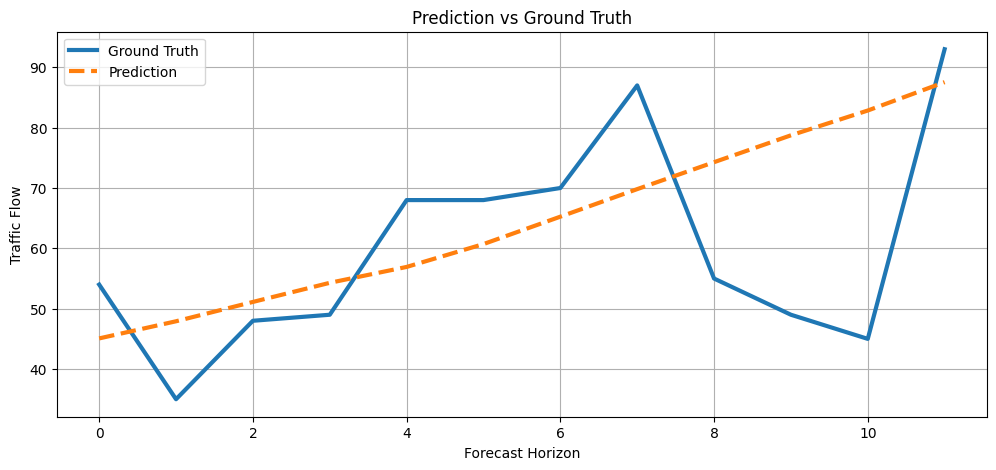

In [153]:
sensor = 0
sample = 0

plt.figure(figsize=(12,5))


plt.plot(
    true_real[sample,:,sensor],
    label="Ground Truth",
    linewidth=3
)


plt.plot(
    pred_real[sample,:,sensor],
    label="Prediction",
    linestyle="--",
    linewidth=3
)


plt.xlabel("Forecast Horizon")

plt.ylabel("Traffic Flow")

plt.title("Prediction vs Ground Truth")

plt.grid(True)

plt.legend()
plt.savefig(
    "results/prediction_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

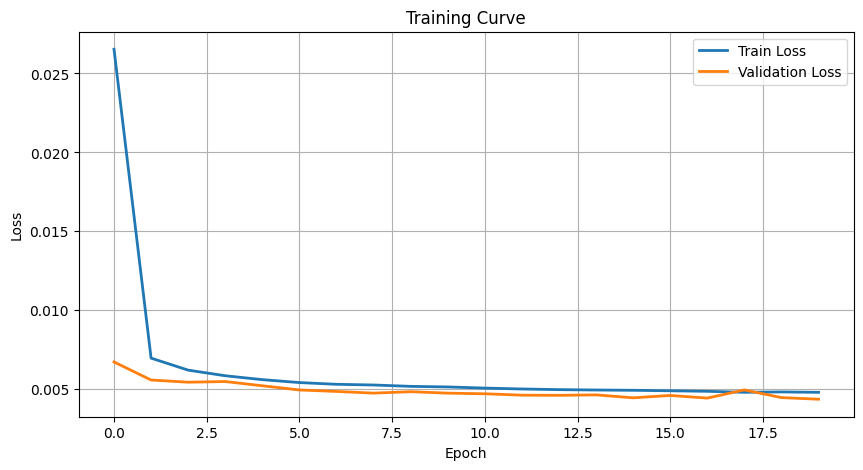

In [152]:
# ============================================================
# Cell 64: Training Curve
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(

    train_losses,

    label="Train Loss",

    linewidth=2

)

plt.plot(

    val_losses,

    label="Validation Loss",

    linewidth=2

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Curve")

plt.grid(True)

plt.legend()
plt.savefig(
    "results/training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [144]:
# ============================================================
# Cell 65: Save Experiment Results
# ============================================================

import pickle
import os


os.makedirs("results", exist_ok=True)


# 1. Save model
torch.save(
    model.state_dict(),
    "results/best_mlcaformer.pth"
)


# 2. Save normalizer
with open(
    "results/normalizer.pkl",
    "wb"
) as f:

    pickle.dump(
        normalizer,
        f
    )


# 3. Save predictions
np.save(
    "results/predictions.npy",
    pred_real
)


# 4. Save ground truth
np.save(
    "results/ground_truth.npy",
    true_real
)


# 5. Save training history

history = {

    "train_loss": train_losses,

    "val_loss": val_losses

}


with open(
    "results/history.pkl",
    "wb"
) as f:

    pickle.dump(
        history,
        f
    )


# 6. Save metrics

metrics = {

    "MAE": mae,

    "RMSE": rmse,

    "MAPE": mape

}


with open(
    "results/metrics.pkl",
    "wb"
) as f:

    pickle.dump(
        metrics,
        f
    )


print("="*60)
print("All Results Saved Successfully")
print("="*60)

All Results Saved Successfully


#SAVE TO reuse


In [144]:
# ============================================================
# Cell 59.5: Save Training Results
# ============================================================

import json

os.makedirs("results", exist_ok=True)


# Save model
torch.save(
    model.state_dict(),
    "results/best_mlcaformer.pth"
)


# Save configuration
config_dict = {
    "INPUT_LENGTH": cfg.INPUT_LENGTH,
    "PRED_LENGTH": cfg.PRED_LENGTH,
    "BATCH_SIZE": cfg.BATCH_SIZE,
    "EPOCHS": cfg.EPOCHS,
    "LEARNING_RATE": cfg.LEARNING_RATE,
    "D_MODEL": cfg.D_MODEL,
    "NUM_HEADS": cfg.NUM_HEADS,
    "NUM_LAYERS": cfg.NUM_LAYERS
}


with open(
    "results/config.json",
    "w"
) as f:

    json.dump(
        config_dict,
        f,
        indent=4
    )


print("Training result saved!")

In [145]:
# ============================================================
# Cell 59.6: Save Normalizer
# ============================================================

np.save(
    "results/data_min.npy",
    normalizer.data_min
)


np.save(
    "results/data_max.npy",
    normalizer.data_max
)


print("Scaler saved!")

Scaler saved!


In [146]:
# ============================================================
# Cell 64.5: Save Loss History
# ============================================================

np.save(
    "results/train_losses.npy",
    train_losses
)

np.save(
    "results/val_losses.npy",
    val_losses
)

print("Loss history saved!")

Loss history saved!


In [147]:
# ============================================================
# Cell 61.6: Save Prediction Result
# ============================================================


np.save(
    "results/predictions.npy",
    pred_real
)


np.save(
    "results/ground_truth.npy",
    true_real
)


print("Prediction saved!")

Prediction saved!


In [151]:
# ============================================================
# Cell 62.5: Save Metrics
# ============================================================

import json
metrics = {

    "MAE": float(mae),

    "RMSE": float(rmse),

    "MAPE": float(mape)

}


with open(
    "results/metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


print(metrics)

{'MAE': 21.997278213500977, 'RMSE': 34.076135100660075, 'MAPE': 13.040945053100586}
